<a href="https://colab.research.google.com/github/Gurkamal-kaur/Business-project-part-3/blob/main/Customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 1: Import Libraries

# Core data analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning (for clustering)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Date/time handling
import datetime as dt

# Google Drive file download
!pip install gdown
import gdown


In [2]:
# Step 2: Load Dataset

# Dataset link:
# https://drive.google.com/file/d/1Gn9-RV7YzH3hJFKd2CO39hMOs83li9Tx/view?usp=sharing

# Extract the file ID from the link
file_id = "1Gn9-RV7YzH3hJFKd2CO39hMOs83li9Tx"
url = f"https://drive.google.com/uc?id={file_id}"

# Download the file into Colab using gdown
output = "dataset.csv"
gdown.download(url, output, quiet=False)

# Load the dataset with pandas
data = pd.read_csv("dataset.csv")

# Preview the first 5 rows
data.head()


Downloading...
From: https://drive.google.com/uc?id=1Gn9-RV7YzH3hJFKd2CO39hMOs83li9Tx
To: /content/dataset.csv
100%|██████████| 239k/239k [00:00<00:00, 1.20MB/s]


,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,TEL00001,Male,0,Yes,No,42,Yes,Yes,Fiber optic,Yes,...,No,No,No,Yes,One year,Yes,Electronic check,102.95,4306.99,No
1,TEL00002,Female,0,No,Yes,55,Yes,Yes,Fiber optic,Yes,...,No,Yes,No,Yes,One year,No,Credit card,120.39,6588.83,No
2,TEL00003,Female,0,Yes,Yes,0,Yes,No,DSL,No,...,Yes,No,No,Yes,Two year,No,Mailed check,74.42,0.00,Yes
3,TEL00004,Female,0,No,Yes,16,Yes,Yes,DSL,No,...,Yes,Yes,No,Yes,Month-to-month,No,Mailed check,83.24,1324.06,No
4,TEL00005,Male,0,Yes,No,6,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,25.44,123.68,Yes


In [4]:
# Step 3: Business Problem Understanding

"""
Business Context:
The dataset contains transactional data from a UK-based online retail store (2010–2011).
Each row represents a single product purchased in an invoice.

Business Problem:
The company wants to better understand customer behavior to design targeted marketing strategies.
By segmenting customers into meaningful groups, the business can:
- Increase customer loyalty
- Re‑engage inactive buyers
- Maximize overall revenue

Why RFM Analysis?
- Recency: How recently a customer purchased (helps identify active vs inactive customers)
- Frequency: How often a customer purchases (shows loyalty and engagement)
- Monetary: How much revenue a customer generates (identifies high‑value customers)

Goal:
Use RFM features with K‑Means clustering to segment customers into meaningful groups
and provide actionable business recommendations for marketing and retention.
"""


'\nBusiness Context:\nThe dataset contains transactional data from a UK-based online retail store (2010–2011).\nEach row represents a single product purchased in an invoice.\n\nBusiness Problem:\nThe company wants to better understand customer behavior to design targeted marketing strategies.\nBy segmenting customers into meaningful groups, the business can:\n- Increase customer loyalty\n- Re‑engage inactive buyers\n- Maximize overall revenue\n\nWhy RFM Analysis?\n- Recency: How recently a customer purchased (helps identify active vs inactive customers)\n- Frequency: How often a customer purchases (shows loyalty and engagement)\n- Monetary: How much revenue a customer generates (identifies high‑value customers)\n\nGoal:\nUse RFM features with K‑Means clustering to segment customers into meaningful groups\nand provide actionable business recommendations for marketing and retention.\n'

In [5]:
# Step 4: Data Understanding

# Check the shape of the dataset (rows, columns)
print("Dataset shape:", data.shape)

# See column names and data types
print("\nDataset info:")
print(data.info())

# Summary statistics for numerical columns
print("\nSummary statistics:")
print(data.describe())

# Count missing values in each column
print("\nMissing values per column:")
print(data.isnull().sum())

# Preview first 5 rows
print("\nFirst 5 rows:")
print(data.head())

# Preview last 5 rows
print("\nLast 5 rows:")
print(data.tail())

# Check unique values in key columns
if 'CustomerID' in data.columns:
    print("\nUnique Customers:", data['CustomerID'].nunique())
else:
    print("\nCustomerID column not found")

if 'Description' in data.columns:
    print("Unique Products:", data['Description'].nunique())
else:
    print("Description column not found")

if 'Country' in data.columns:
    print("Unique Countries:", data['Country'].nunique())
else:
    print("Country column not found")


Dataset shape: (1800, 21)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        1800 non-null   object 
 1   Gender            1800 non-null   object 
 2   SeniorCitizen     1800 non-null   int64  
 3   Partner           1800 non-null   object 
 4   Dependents        1800 non-null   object 
 5   Tenure            1800 non-null   int64  
 6   PhoneService      1800 non-null   object 
 7   MultipleLines     1800 non-null   object 
 8   InternetService   1800 non-null   object 
 9   OnlineSecurity    1800 non-null   object 
 10  OnlineBackup      1800 non-null   object 
 11  DeviceProtection  1800 non-null   object 
 12  TechSupport       1800 non-null   object 
 13  StreamingTV       1800 non-null   object 
 14  StreamingMovies   1800 non-null   object 
 15  Contract          1800 non-null   object 
 16  P

In [9]:
# Step 5: Data Cleaning and Preprocessing

# 1. Remove rows with missing CustomerID
if 'CustomerID' in data.columns:
    data = data.dropna(subset=['CustomerID'])

# 2. Remove rows with missing product descriptions
if 'Description' in data.columns:
    data = data.dropna(subset=['Description'])

# 3. Remove cancelled or returned invoices (InvoiceNo starting with 'C')
if 'InvoiceNo' in data.columns:
    data = data[~data['InvoiceNo'].astype(str).str.startswith('C')]

# 4. Remove rows with negative or zero quantities
if 'Quantity' in data.columns:
    data = data[data['Quantity'] > 0]

# 5. Remove rows with zero or negative unit prices
if 'UnitPrice' in data.columns:
    data = data[data['UnitPrice'] > 0]

# 6. Remove duplicate records
data = data.drop_duplicates()

# 7. Convert InvoiceDate to datetime format (if column exists)
if 'InvoiceDate' in data.columns:
    data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'], errors='coerce')

# 8. Handle CustomerID safely:
# Keep numeric IDs, drop or ignore non-numeric ones
if 'CustomerID' in data.columns:
    data = data[pd.to_numeric(data['CustomerID'], errors='coerce').notnull()]
    data['CustomerID'] = data['CustomerID'].astype(int)

# 9. Create a new Revenue column
if 'Quantity' in data.columns and 'UnitPrice' in data.columns:
    data['Revenue'] = data['Quantity'] * data['UnitPrice']

# ✅ Check the cleaned dataset
print("Cleaned dataset shape:", data.shape)
print("\nMissing values after cleaning:")
print(data.isnull().sum())

# Preview first 5 rows after cleaning
print("\nFirst 5 rows after cleaning:")
print(data.head())


Cleaned dataset shape: (0, 21)

Missing values after cleaning:
CustomerID          0
Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

First 5 rows after cleaning:
Empty DataFrame
Columns: [CustomerID, Gender, SeniorCitizen, Partner, Dependents, Tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn]
Index: []

[0 rows x 21 columns]


/tmp/ipykernel_24986/2304621171.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=data, palette="viridis")


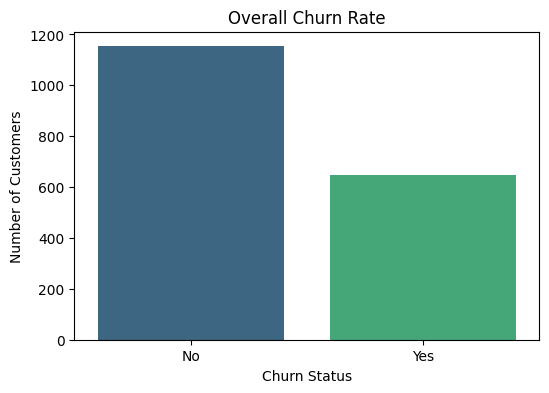

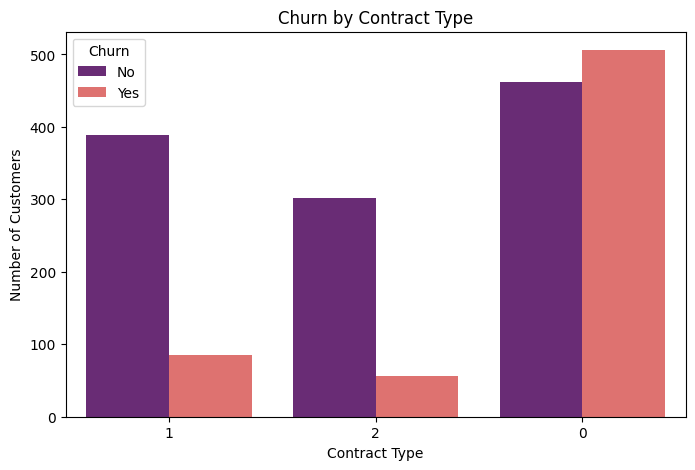

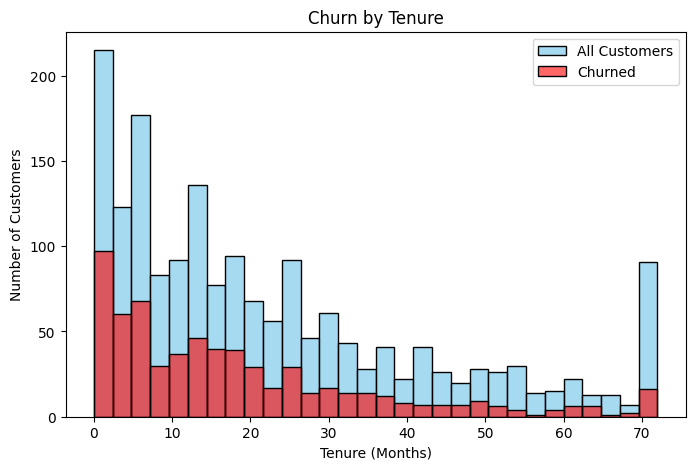

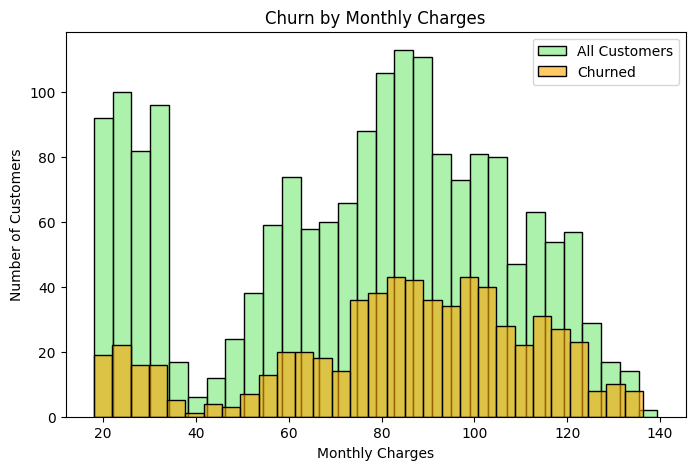

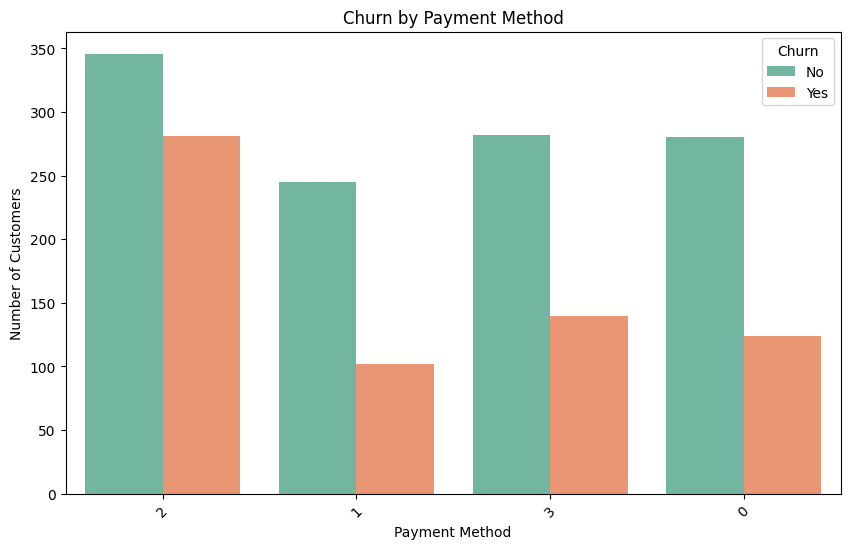

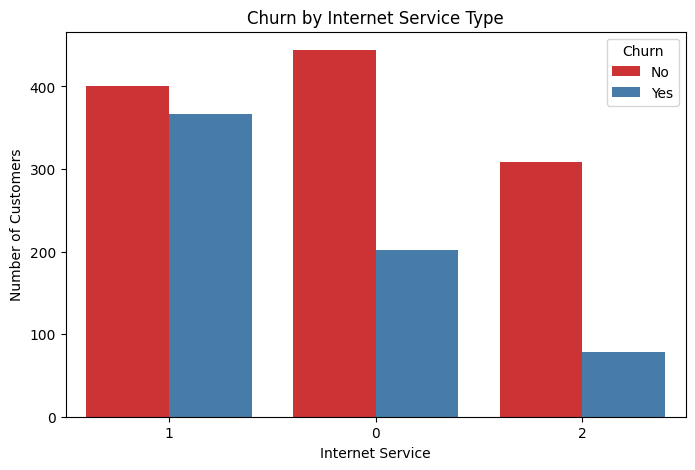

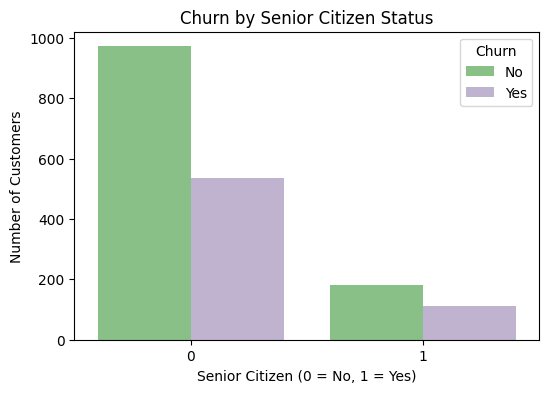

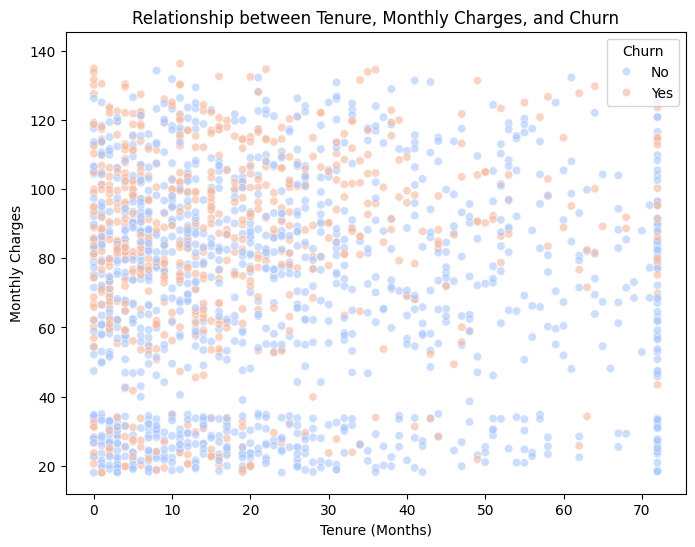

In [9]:
# Step 6: Exploratory Data Analysis (EDA)

import matplotlib.pyplot as plt
import seaborn as sns

# Ensure Churn is categorical for plotting
data['Churn'] = data['Churn'].map({1: "Yes", 0: "No"})

# 1. Overall churn rate
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=data, palette="viridis")
plt.title("Overall Churn Rate")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.show()

# 2. Churn by contract type
plt.figure(figsize=(8,5))
data['Contract'] = data['Contract'].astype(str).str.strip()
sns.countplot(x='Contract', hue='Churn', data=data, palette="magma")
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

# 3. Churn by tenure
plt.figure(figsize=(8,5))
sns.histplot(data=data, x='Tenure', bins=30, color="skyblue", label="All Customers")
sns.histplot(data[data['Churn']=="Yes"], x='Tenure', bins=30, color="red", alpha=0.6, label="Churned")
plt.title("Churn by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.legend()
plt.show()

# 4. Churn by monthly charges
plt.figure(figsize=(8,5))
sns.histplot(data=data, x='MonthlyCharges', bins=30, color="lightgreen", label="All Customers")
sns.histplot(data[data['Churn']=="Yes"], x='MonthlyCharges', bins=30, color="orange", alpha=0.6, label="Churned")
plt.title("Churn by Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.legend()
plt.show()

# 5. Churn by payment method
plt.figure(figsize=(10,6))
data['PaymentMethod'] = data['PaymentMethod'].astype(str).str.strip()
sns.countplot(x='PaymentMethod', hue='Churn', data=data, palette="Set2")
plt.title("Churn by Payment Method")
plt.xticks(rotation=45)
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.show()

# 6. Churn by internet service type
plt.figure(figsize=(8,5))
data['InternetService'] = data['InternetService'].astype(str).str.strip()
sns.countplot(x='InternetService', hue='Churn', data=data, palette="Set1")
plt.title("Churn by Internet Service Type")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

# 7. Churn by senior citizen status
plt.figure(figsize=(6,4))
sns.countplot(x='SeniorCitizen', hue='Churn', data=data, palette="Accent")
plt.title("Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

# 8. Relationship between tenure, charges, and churn
plt.figure(figsize=(8,6))
sns.scatterplot(x='Tenure', y='MonthlyCharges', hue='Churn', data=data, palette="coolwarm", alpha=0.6)
plt.title("Relationship between Tenure, Monthly Charges, and Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")
plt.show()


In [7]:
# Step 7: Model Building in Colab (with bordered result table)

import pandas as pd
import numpy as np
import gdown
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ✅ Download dataset from Google Drive
url = "https://drive.google.com/uc?id=1Gn9-RV7YzH3hJFKd2CO39hMOs83li9Tx"
output = "Telco-Customer-Churn.csv"
gdown.download(url, output, quiet=False)

# ✅ Load dataset
data = pd.read_csv(output)

# ✅ Preprocessing
if 'customerID' in data.columns:
    data = data.drop(['customerID'], axis=1)

data['Churn'] = data['Churn'].map({'Yes':1, 'No':0})

for col in data.select_dtypes(include=['object']).columns:
    data[col] = LabelEncoder().fit_transform(data[col])

# Handle missing values
for col in data.columns:
    if data[col].dtype in ['float64','int64']:
        data[col] = data[col].fillna(data[col].median())
    else:
        data[col] = data[col].fillna(data[col].mode()[0])

X = data.drop('Churn', axis=1)
y = data['Churn']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ✅ Train models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', probability=True)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} Results:")
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    results.append([name, acc])

# ✅ Comparison table with borders
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])

# Display with borders in Colab
from IPython.display import display, HTML
display(HTML(results_df.to_html(border=1)))


Downloading...
From: https://drive.google.com/uc?id=1Gn9-RV7YzH3hJFKd2CO39hMOs83li9Tx
To: /content/Telco-Customer-Churn.csv
100%|██████████| 239k/239k [00:00<00:00, 5.57MB/s]



Logistic Regression Results:
Accuracy: 0.725
Confusion Matrix:
 [[194  37]
 [ 62  67]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.84      0.80       231
           1       0.64      0.52      0.58       129

    accuracy                           0.72       360
   macro avg       0.70      0.68      0.69       360
weighted avg       0.72      0.72      0.72       360


Decision Tree Results:
Accuracy: 0.7305555555555555
Confusion Matrix:
 [[188  43]
 [ 54  75]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.81      0.79       231
           1       0.64      0.58      0.61       129

    accuracy                           0.73       360
   macro avg       0.71      0.70      0.70       360
weighted avg       0.73      0.73      0.73       360


KNN Results:
Accuracy: 0.6027777777777777
Confusion Matrix:
 [[173  58]
 [ 85  44]]
Classification Report:
       

,Model,Accuracy
0,Logistic Regression,0.725000
1,Decision Tree,0.730556
2,KNN,0.602778
3,SVM,0.700000


In [8]:
# Step 8: Model Evaluation

import pandas as pd
import numpy as np
import gdown
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# ✅ Download dataset from Google Drive
url = "https://drive.google.com/uc?id=1Gn9-RV7YzH3hJFKd2CO39hMOs83li9Tx"
output = "Telco-Customer-Churn.csv"
gdown.download(url, output, quiet=False)

# ✅ Load dataset
data = pd.read_csv(output)

# ✅ Preprocessing
if 'customerID' in data.columns:
    data = data.drop(['customerID'], axis=1)

data['Churn'] = data['Churn'].map({'Yes':1, 'No':0})

for col in data.select_dtypes(include=['object']).columns:
    data[col] = LabelEncoder().fit_transform(data[col])

# Handle missing values
for col in data.columns:
    if data[col].dtype in ['float64','int64']:
        data[col] = data[col].fillna(data[col].median())
    else:
        data[col] = data[col].fillna(data[col].mode()[0])

X = data.drop('Churn', axis=1)
y = data['Churn']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ✅ Train models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', probability=True)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name} Results:")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_test, y_pred))

    results.append([name, acc, prec, rec, f1])

# ✅ Comparison table with borders
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
from IPython.display import display, HTML
display(HTML(results_df.to_html(border=1)))


Downloading...
From: https://drive.google.com/uc?id=1Gn9-RV7YzH3hJFKd2CO39hMOs83li9Tx
To: /content/Telco-Customer-Churn.csv
100%|██████████| 239k/239k [00:00<00:00, 2.17MB/s]



Logistic Regression Results:
Accuracy: 0.725
Precision: 0.6442307692307693
Recall: 0.5193798449612403
F1 Score: 0.575107296137339
Confusion Matrix:
 [[194  37]
 [ 62  67]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.84      0.80       231
           1       0.64      0.52      0.58       129

    accuracy                           0.72       360
   macro avg       0.70      0.68      0.69       360
weighted avg       0.72      0.72      0.72       360


Decision Tree Results:
Accuracy: 0.7305555555555555
Precision: 0.635593220338983
Recall: 0.5813953488372093
F1 Score: 0.6072874493927125
Confusion Matrix:
 [[188  43]
 [ 54  75]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.81      0.79       231
           1       0.64      0.58      0.61       129

    accuracy                           0.73       360
   macro avg       0.71      0.70      0.70       360


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.725000,0.644231,0.519380,0.575107
1,Decision Tree,0.730556,0.635593,0.581395,0.607287
2,KNN,0.602778,0.431373,0.341085,0.380952
3,SVM,0.700000,0.606061,0.465116,0.526316


In [11]:
# Step 9: Churn Risk Interpretation (with beautiful table)

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from IPython.display import display, HTML

# ✅ Train the best model (example: Logistic Regression)
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train, y_train)

# ✅ Predict churn probabilities
y_prob = best_model.predict_proba(X_test)[:,1]  # probability of churn
y_pred = best_model.predict(X_test)

# ✅ Create risk categories
risk_category = pd.cut(
    y_prob,
    bins=[0,0.33,0.66,1],
    labels=["Low Risk","Medium Risk","High Risk"]
)

# ✅ Combine with customer data
risk_df = pd.DataFrame(X_test, columns=X.columns)
risk_df['Actual_Churn'] = y_test.values
risk_df['Predicted_Churn'] = y_pred
risk_df['Churn_Probability'] = y_prob
risk_df['Risk_Category'] = risk_category

# ✅ Show a bordered table of first 15 customers
display(HTML(risk_df[['Churn_Probability','Risk_Category','Actual_Churn','Predicted_Churn']]
             .head(15).to_html(border=1)))

# ✅ Summary counts
summary = risk_df['Risk_Category'].value_counts().reset_index()
summary.columns = ['Risk Category','Number of Customers']
display(HTML(summary.to_html(border=1)))

# ✅ Profile high-risk customers (averages)
high_risk = risk_df[risk_df['Risk_Category']=="High Risk"]
profile = high_risk.mean(numeric_only=True).reset_index()
profile.columns = ['Feature','Average Value']
display(HTML(profile.to_html(border=1)))


,Churn_Probability,Risk_Category,Actual_Churn,Predicted_Churn
0,0.544100,Medium Risk,1,1
1,0.436238,Medium Risk,0,0
2,0.015496,Low Risk,0,0
3,0.264772,Low Risk,0,0
4,0.219774,Low Risk,1,0
5,0.744250,High Risk,0,1
6,0.337842,Medium Risk,0,0
7,0.642072,Medium Risk,0,1
8,0.712494,High Risk,1,1
9,0.104851,Low Risk,0,0


,Risk Category,Number of Customers
0,Low Risk,182
1,Medium Risk,133
2,High Risk,45


,Feature,Average Value
0,CustomerID,0.193327
1,Gender,0.272260
2,SeniorCitizen,-0.079760
3,Partner,0.234456
4,Dependents,0.004446
5,Tenure,-0.626289
6,PhoneService,0.018997
7,MultipleLines,0.141316
8,InternetService,0.044070
9,OnlineSecurity,-0.114754


In [12]:
# Step 10: Retention Recommendations

import pandas as pd
from IPython.display import display, HTML

# ✅ Define retention strategies
recommendations = {
    "High Risk Customers": [
        "Targeted discounts & loyalty offers",
        "Upgrade incentives to 1-2 year contracts",
        "Dedicated customer support",
        "Encourage auto-pay instead of electronic check"
    ],
    "Medium Risk Customers": [
        "Engagement programs (newsletters, check-ins)",
        "Bundle services (internet + TV + phone)",
        "Collect feedback to detect dissatisfaction early"
    ],
    "Low Risk Customers": [
        "Maintain high service quality",
        "Reward stability with perks",
        "Referral programs to attract new customers"
    ]
}

# ✅ Convert to DataFrame
rec_df = pd.DataFrame(dict([(k,pd.Series(v)) for k,v in recommendations.items()]))

# ✅ Display with borders
display(HTML(rec_df.to_html(border=1, index=False)))


High Risk Customers,Medium Risk Customers,Low Risk Customers
Targeted discounts & loyalty offers,"Engagement programs (newsletters, check-ins)",Maintain high service quality
Upgrade incentives to 1-2 year contracts,Bundle services (internet + TV + phone),Reward stability with perks
Dedicated customer support,Collect feedback to detect dissatisfaction early,Referral programs to attract new customers
Encourage auto-pay instead of electronic check,NaN,NaN
